In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
data = "data/"
train = pd.read_csv(data + "mnist_train.csv")
test = pd.read_csv(data + "mnist_test.csv")

In [4]:
train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Data shape: 60000 images, 784 pixel per image (60000, 784)
Convetion for Neural Network: column = Training item (e.g. 7), row = features
Reshape to (784, 60000)

In [6]:
train = np.array(train)
test = np.array(test)

X_train = train[:, 1:].T / 255.0
Y_train = train[:, 0].reshape(1, -1)

X_test = test[:, 1:].T / 255.0
Y_test = test[:, 0].reshape(1, -1)

print(X_train.shape)  # (784, 60000)
print(Y_train.shape)  # (1, 60000)

(784, 60000)
(1, 60000)


Input Layer: 784 Inputs
Hidden Layer: 128 Neurons
Output Layer: 10 Output-Neurons

Initilaize random Weights and Bias using He-Initilaization (N(0.2/n_in)


In [7]:
def init_params():
    W1 = np.random.randn(128,784)*0.01
    b1 = np.zeros((128,1))
    W2 = np.random.randn(10,128)*0.01
    b2 = np.zeros((10,1))
    return W1,b1,W2,b2

ReLU Activation for Hidden-Neurons: max(v,0)

In [8]:
def ReLU(z): return np.maximum(z,0)

Softmax for Output-Layer: exp(v) / sum exp(v)

In [9]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Forward propagation:
Hidden-Layer Input: Z1 = W1*X+b1
Hidden-Layer Activation: A1 = ReLU(Z1)
Output-Layer Input: Z2 = W2*A1 + b2
Output-Layer Activation: A2 = Softmax(Z2)

In [10]:
def forward(X, W1,W2,b1,b2):
    Z1 = W1 @ X + b1
    A1 = ReLU(Z1)
    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

One-Hot-Encoding for True Label

In [11]:
def one_hot(Y):
    Y = Y.flatten().astype(int)
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size),Y] = 1
    return one_hot_Y.T

Back propagation:

In [12]:
def backward(X, Z1, A1, A2, W2, Y):
    m = Y.size
    one_hot_Y = one_hot(Y.flatten())

    #Output Layer
    dZ2 = A2 - one_hot_Y
    dW2 = (1/m) * dZ2 @ A1.T
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    #Hidden Layer
    dZ1 = (W2.T @ dZ2) * (Z1 > 0)
    dW1 = (1/m) * dZ1 @ X.T
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

In [13]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

Gradient Descend

In [14]:
def compute_loss(A2,Y):
    Y_one_hot = one_hot(Y)
    m = Y.size
    loss = -np.sum(Y_one_hot * np.log(A2 + 1e-8))/m
    return loss

def gradient_descent(X, Y, alpha, tolerance=1e-6, max_iterations = 10000):
    W1, b1, W2, b2 = init_params()
    old_loss = float("inf")
    for i in range(max_iterations):
        Z1, A1, Z2, A2 = forward(X, W1, W2, b1, b2)
        dW1, db1, dW2, db2 = backward(X, Z1, A1, A2, W2, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        loss = compute_loss(A2,Y)
        if abs(old_loss - loss) < tolerance:
            print("Converges after", i, "iterations")
            break
        old_loss = loss

    return W1, b1, W2, b2


In [16]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train,alpha=0.001)

def get_predictions(A2): return np.argmax(A2, axis=0)
def get_accuracy(predictions, Y): return np.mean(predictions == Y.flatten())

Z1, A1, Z2, A2 = forward(X_test, W1, W2, b1, b2)

predictions = get_predictions(A2)
accuracy = get_accuracy(predictions, Y_test)

print(accuracy)

Converges after 1038 iterations
0.5293


In [17]:
def test_prediction(index, X, Y, W1, b1, W2, b2):
    current_image = X[:, index].reshape(28, 28)

    Z1, A1, Z2, A2 = forward(X[:, index:index+1], W1, W2, b1, b2)

    prediction = np.argmax(A2, axis=0)[0]
    label = Y.flatten()[index]

    print("Prediction:", prediction)
    print("Actual label:", label)

    plt.imshow(current_image, cmap="gray")
    plt.axis("off")
    plt.show()

Prediction: 0
Actual label: 3


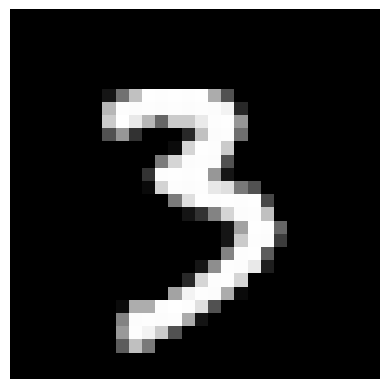

In [23]:
test_prediction(30, X_test, Y_test, W1, b1, W2, b2)